# Getting baseline ARIMA model running

## 0.0 Setup

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
### MOVE TO REQUIREMENTS ###
!pip install statsmodels

## 0.1 Data import

Importing electricity price data for Germany from February 2025 to February 2026!

ALERT: Data has to be in raw_data folder!!

In [8]:
path = "../javier/raw_data/"
file = "combined_energy_price_clean.csv"
route = path + file

In [9]:
data = pd.read_csv(route, sep='\t')

/var/folders/6p/0b4w1hy94rg79cl81qv1csjc0000gn/T/ipykernel_92303/2900955338.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(route, sep='\t')


In [10]:
data = data[["DateTime(UTC)", "Price[Currency/MWh]","Sequence"]]

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378307 entries, 0 to 378306
Data columns (total 3 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   DateTime(UTC)        378307 non-null  object 
 1   Price[Currency/MWh]  378307 non-null  float64
 2   Sequence             378307 non-null  object 
dtypes: float64(1), object(2)
memory usage: 8.7+ MB


## 1.0 Data cleaning

In [12]:
#choosing sequence 2 for 15 minutes intervals
data_2 = data[data["Sequence"] == 2]
data_2.drop(columns="Sequence", inplace=True)
len(data_2)

/var/folders/6p/0b4w1hy94rg79cl81qv1csjc0000gn/T/ipykernel_92303/1307687556.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2.drop(columns="Sequence", inplace=True)


186230

In [13]:
data_2["date"] = pd.to_datetime(data_2["DateTime(UTC)"], format="%Y-%m-%d %H:%M:%S")
data_2.rename(columns={"Price[Currency/MWh]":"price"}, inplace=True)
data_2.drop(columns="DateTime(UTC)", inplace=True)
data_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186230 entries, 131072 to 378306
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   price   186230 non-null  float64       
 1   date    186230 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.3 MB


/var/folders/6p/0b4w1hy94rg79cl81qv1csjc0000gn/T/ipykernel_92303/3846443639.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2["date"] = pd.to_datetime(data_2["DateTime(UTC)"], format="%Y-%m-%d %H:%M:%S")
/var/folders/6p/0b4w1hy94rg79cl81qv1csjc0000gn/T/ipykernel_92303/3846443639.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2.rename(columns={"Price[Currency/MWh]":"price"}, inplace=True)
/var/folders/6p/0b4w1hy94rg79cl81qv1csjc0000gn/T/ipykernel_92303/3846443639.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [14]:
start_date = pd.to_datetime("2025-02-01 00:00:00", format="%Y-%m-%d %H:%M:%S")
end_date = pd.to_datetime("2026-02-01 00:00:00", format="%Y-%m-%d %H:%M:%S")
date_boolean_mask = (data_2["date"] >= start_date) & (data_2["date"] <= end_date)

In [15]:
data_bm = data_2[date_boolean_mask]

<Axes: xlabel='date', ylabel='price'>

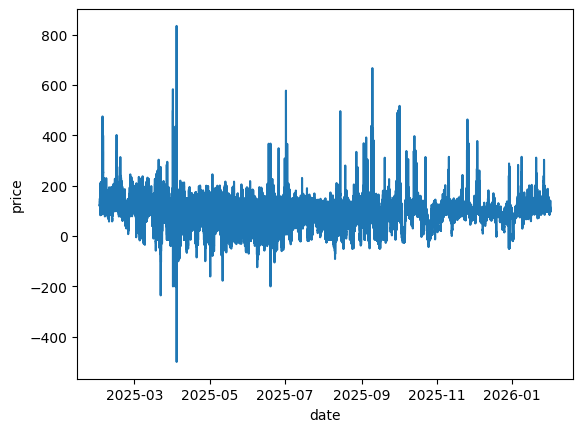

In [16]:
sns.lineplot(data=data_bm, x=data_bm["date"],y=data_bm["price"])

## 2.0 Analysis

### 2.1 Stationarity

In [17]:
X = data_bm["date"]
y = data_bm["price"]

In [18]:
from statsmodels.tsa.stattools import adfuller

df1_result = adfuller(y)[1]
df1_result

np.float64(2.1035424490159925e-30)

### 2.2 AR and MA processes

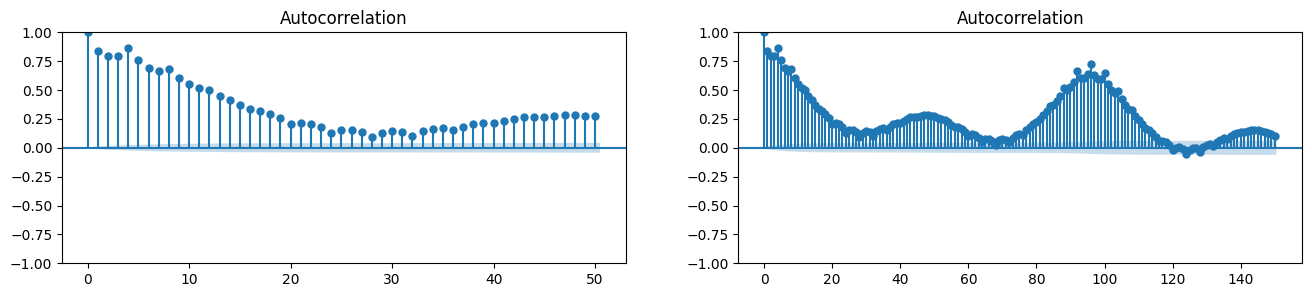

In [19]:
from statsmodels.graphics.tsaplots import plot_acf
fig, axes = plt.subplots(1,2, figsize=(16,3))

plot_acf(y, lags=50, ax=axes[0]);
plot_acf(y, lags=150, ax=axes[1]);

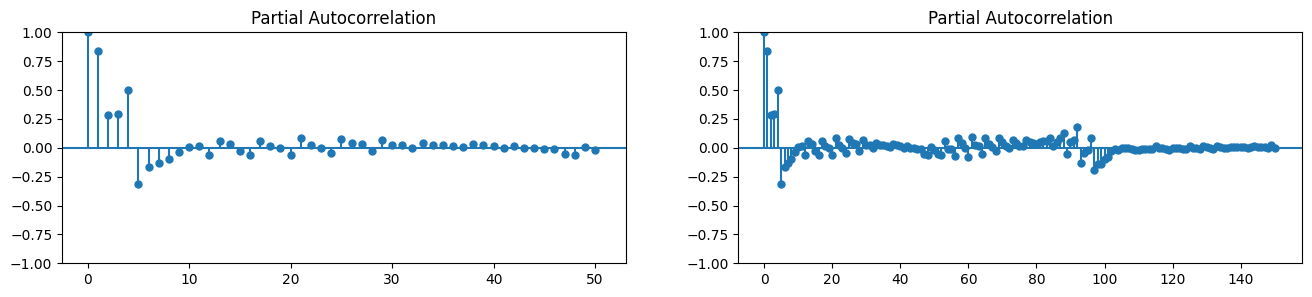

In [20]:
from statsmodels.graphics.tsaplots import plot_pacf
fig, axes = plt.subplots(1,2, figsize=(16,3))

plot_pacf(y, lags=50, ax=axes[0]);
plot_pacf(y, lags=150, ax=axes[1]);

### Notes

Although df1_result is practically 0, we have a lot of significant autocorrelation and partial autocorellation. Such high numbers for p and q as well as their shape (cyclicity) suggest there are a lot of patterns we are not accounting for!

## 3.0 Preliminary model

In [21]:
#a shot in the dark, keep it simple
type(y)

pandas.core.series.Series

In [22]:
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import numpy as np

y = data_bm["price"]

ts_cv = TimeSeriesSplit(n_splits=5)
mae_list = []

for train_index, test_index in ts_cv.split(y):
    train, test = y.iloc[train_index], y.iloc[test_index]

    # Fit ARIMA on train
    model = ARIMA(train, order=(2,0,2))  # replace with your orders
    model_fit = model.fit()

    # Forecast for test length
    forecast = model_fit.forecast(steps=len(test))

    # Calculate MAE
    mae = mean_absolute_error(test, forecast)
    mae_list.append(mae)

# Average MAE over all folds
avg_mae = np.mean(mae_list)
print(f'Average MAE across folds: {avg_mae}')

/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.


Average MAE across folds: 38.92801836750792


/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [145]:
len(train), len(test)

(29201, 5840)